# HSK Vocabulary — Exploratory Analysis

A closer look at the ~11,000-word New HSK 3.0 vocabulary parsed in this
project (`vocab/*.csv`): how word length, part of speech, and individual
characters are distributed across the seven levels, and what that implies
for study order.


In [1]:
import csv
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

# A CJK-capable font so hanzi render correctly in axis labels/tick text below.
# Falls back to boxes if the notebook is re-run on a machine without one installed.
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "Noto Sans CJK SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

LEVELS = ["01", "02", "03", "04", "05", "06", "07_09"]
LEVEL_LABELS = {"01": "H1", "02": "H2", "03": "H3", "04": "H4", "05": "H5", "06": "H6", "07_09": "HSK 7-9"}

frames = []
for lvl in LEVELS:
    df = pd.read_csv(f"../vocab/hsk_level_{lvl}.csv", keep_default_na=False)
    df["Level"] = LEVEL_LABELS[lvl]
    frames.append(df)

vocab = pd.concat(frames, ignore_index=True)
vocab["Level"] = pd.Categorical(vocab["Level"], categories=list(LEVEL_LABELS.values()), ordered=True)
vocab["Length"] = vocab["Word"].str.len()
vocab.head()


,Word,Pinyin,POS,Translation,Level,Length
0,爱,ài,verb,to love,H1,1
1,八,bā,number,eight,H1,1
2,爸爸,bàba,noun,dad,H1,2
3,吧,ba,auxiliary,"particle indicating suggestion, confirmation, ...",H1,1
4,白天,báitiān,noun,daytime,H1,2


## 1. How many words per level, and how long are they?

HSK is a cumulative curriculum, so the level sizes below aren't arbitrary —
each level roughly doubles or more the vocabulary of the one before it,
until HSK 7-9 alone holds half the entire list.


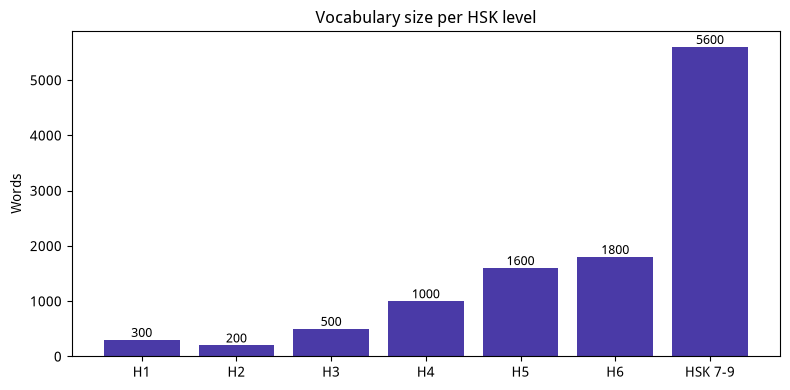

In [2]:
counts = vocab["Level"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.index.astype(str), counts.values, color="#4a3aa7")
ax.set_ylabel("Words")
ax.set_title("Vocabulary size per HSK level")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


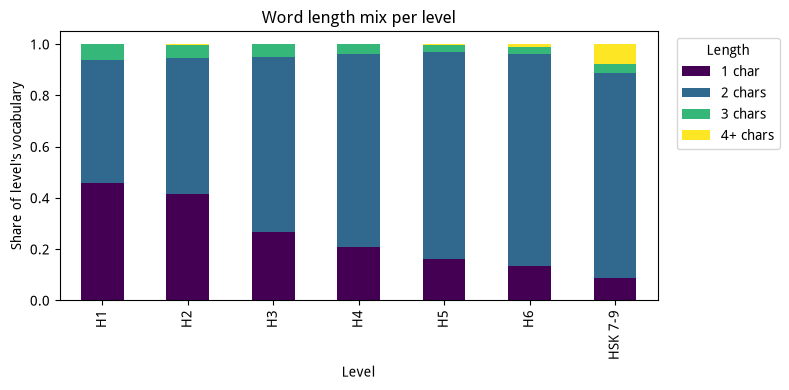

In [3]:
length_dist = pd.crosstab(vocab["Level"], vocab["Length"].clip(upper=4))
length_dist.columns = ["1 char", "2 chars", "3 chars", "4+ chars"]
length_share = length_dist.div(length_dist.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
length_share.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_ylabel("Share of level's vocabulary")
ax.set_title("Word length mix per level")
ax.legend(title="Length", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Single-character words dominate H1 (they're the highest-frequency, most
"load-bearing" words in the language), then give way to two-character
words — the overwhelming default pattern in modern Mandarin — and by HSK
6 / 7-9 a real tail of 3-4+ character words (idioms, technical terms)
appears.


### 1b. Does the average word get longer at higher levels?

The stacked chart above shows the *mix* shifting toward longer words: this
looks at the trend directly, as a single number per level.


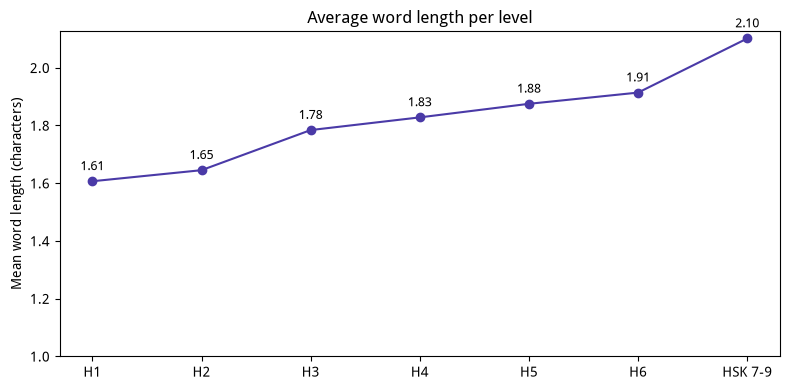

In [4]:
mean_len = vocab.groupby("Level", observed=True)["Length"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mean_len.index.astype(str), mean_len.values, marker="o", color="#4a3aa7")
for i, val in enumerate(mean_len.values):
    ax.annotate(f"{val:.2f}", (i, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_ylabel("Mean word length (characters)")
ax.set_title("Average word length per level")
ax.set_ylim(bottom=1)
plt.tight_layout()
plt.show()


## 2. Part of speech mix

The source PDFs are inconsistent: HSK 1-5 label part of speech in English
(`noun`, `verb`, ...), while HSK 6 and HSK 7-9 use single Chinese characters
(`名`, `动`, ...) instead. Entries can also list more than one POS separated
by `、` (e.g. `noun、verb`). The cell below normalizes both schemes into one
tag set so levels are actually comparable.


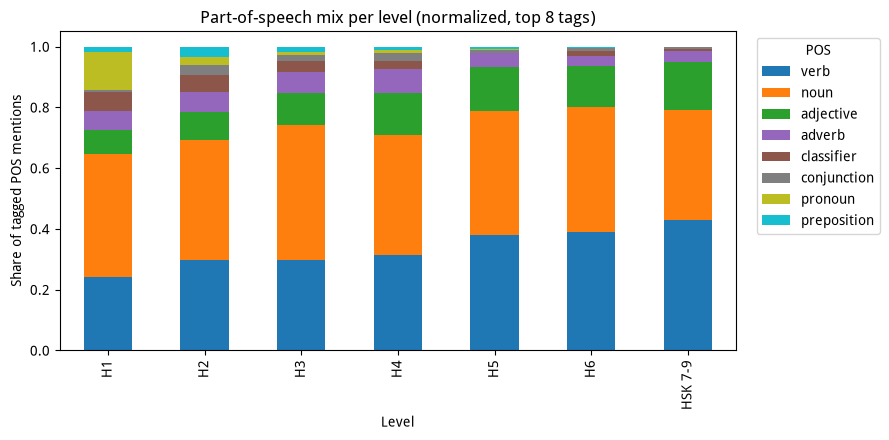

In [5]:
POS_MAP = {
    "noun": "noun", "verb": "verb", "adjective": "adjective", "adverb": "adverb",
    "classifier": "classifier", "conjunction": "conjunction", "pronoun": "pronoun",
    "number": "number", "preposition": "preposition", "auxiliary": "auxiliary",
    "interjection": "interjection", "prefix": "prefix", "suffix": "suffix",
    "名": "noun", "动": "verb", "形": "adjective", "副": "adverb", "量": "classifier",
    "连": "conjunction", "代": "pronoun", "数": "number", "介": "preposition",
    "助": "auxiliary", "叹": "interjection",
}

def normalize_pos(raw):
    tags = []
    for tok in re.split("、", raw):
        tok = tok.strip(" ()（）")
        if tok in POS_MAP:
            tags.append(POS_MAP[tok])
    return tags

pos_exploded = vocab[["Level", "POS"]].copy()
pos_exploded["tags"] = pos_exploded["POS"].map(normalize_pos)
pos_exploded = pos_exploded.explode("tags").dropna(subset=["tags"])

top_pos = pos_exploded["tags"].value_counts().head(8).index
pos_pivot = pd.crosstab(pos_exploded["Level"], pos_exploded["tags"])[top_pos]
pos_share = pos_pivot.div(pos_pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
pos_share.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("Share of tagged POS mentions")
ax.set_title("Part-of-speech mix per level (normalized, top 8 tags)")
ax.legend(title="POS", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Nouns and verbs dominate every level, as expected, but adjectives and
classifiers ('measure words') pick up share in the mid levels — consistent
with how HSK front-loads bare survival vocabulary (H1-H2) before layering
in the descriptive and grammatical vocabulary needed for fluent sentences.


### 2b. Data completeness, and how often words wear more than one POS tag

A word can be genuinely polyfunctional (e.g. `工作` is both "to work" and
"job") — the source marks that with multiple `、`-separated tags. Separately,
some entries have no POS at all; that gap is worth tracking per level since
it's a data-quality signal, not just a linguistic one.


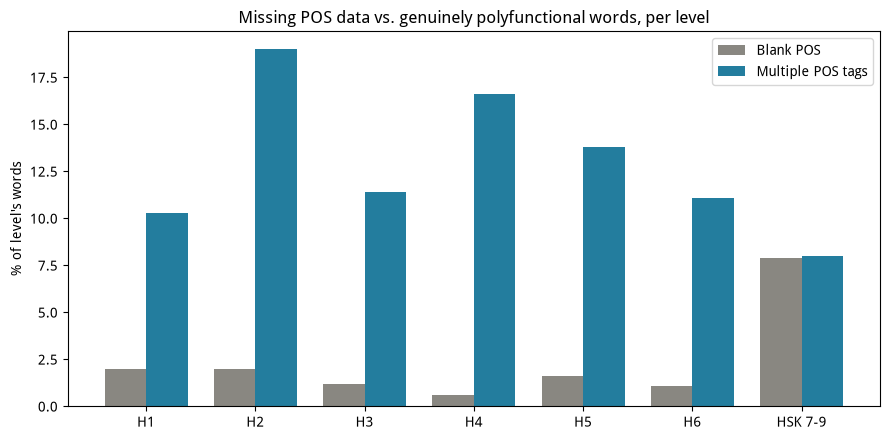

,blank_pos_pct,multi_pos_pct
Level,,
H1,2.0,10.3
H2,2.0,19.0
H3,1.2,11.4
H4,0.6,16.6
H5,1.6,13.8
H6,1.1,11.1
HSK 7-9,7.9,8.0


In [6]:
completeness = vocab.copy()
completeness["pos_tags"] = completeness["POS"].map(normalize_pos)
completeness["n_tags"] = completeness["pos_tags"].map(len)
completeness["is_blank"] = completeness["POS"].str.strip() == ""

per_level = completeness.groupby("Level", observed=True).agg(
    blank_pos_pct=("is_blank", lambda s: round(100 * s.mean(), 1)),
    multi_pos_pct=("n_tags", lambda s: round(100 * (s > 1).mean(), 1)),
)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(per_level))
width = 0.38
ax.bar([i - width / 2 for i in x], per_level["blank_pos_pct"], width, label="Blank POS", color="#898781")
ax.bar([i + width / 2 for i in x], per_level["multi_pos_pct"], width, label="Multiple POS tags", color="#237d9e")
ax.set_xticks(list(x))
ax.set_xticklabels(per_level.index.astype(str))
ax.set_ylabel("% of level's words")
ax.set_title("Missing POS data vs. genuinely polyfunctional words, per level")
ax.legend()
plt.tight_layout()
plt.show()

per_level


HSK 7-9 stands out with a much higher blank-POS rate than every other
level — the source PDF for that tier is visibly less carefully annotated
than the rest, which matches what turned up earlier while building the PDF
parser (that level's table doesn't even have a translation column). The
polyfunctional-word share, by contrast, climbs steadily through the middle
levels: as vocabulary grows, more of it does double duty grammatically.


## 3. Which characters carry the most weight?

Chinese words are built out of a much smaller set of reusable characters.
Breaking every word into its individual hanzi shows which characters are
the highest-leverage to learn first, since they reappear across the most
words.


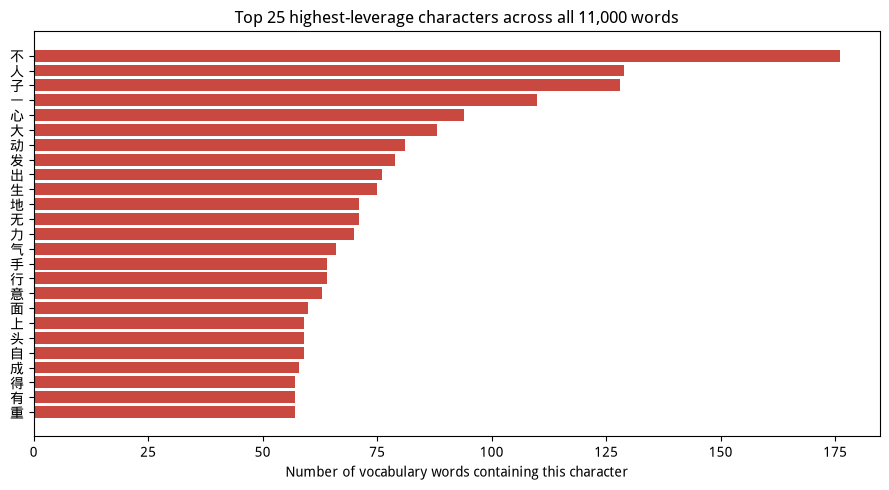

In [7]:
CJK = re.compile(r"[\u4e00-\u9fff]")
char_counter = Counter()
for word in vocab["Word"]:
    char_counter.update(CJK.findall(word))

top_chars = char_counter.most_common(25)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([c for c, _ in top_chars][::-1], [n for _, n in top_chars][::-1], color="#c94940")
ax.set_xlabel("Number of vocabulary words containing this character")
ax.set_title("Top 25 highest-leverage characters across all 11,000 words")
plt.tight_layout()
plt.show()


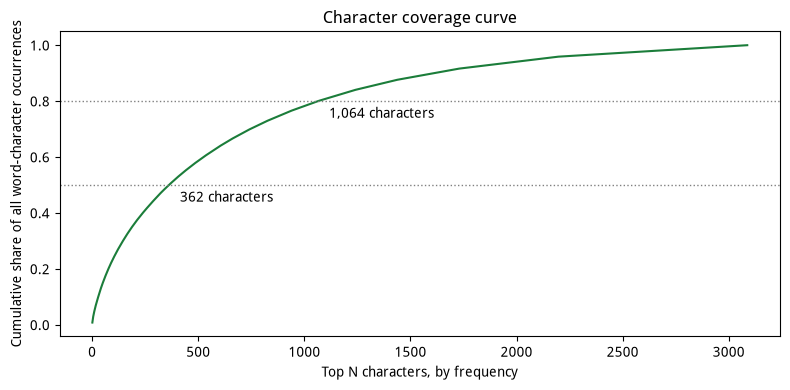

3,087 unique hanzi appear across the ~11,000-word HSK 1-9 list.


In [8]:
freqs = sorted(char_counter.values(), reverse=True)
cum_share = pd.Series(freqs).cumsum() / sum(freqs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum_share) + 1), cum_share.values, color="#1b7d3a")
for target in (0.5, 0.8):
    n_needed = int((cum_share >= target).idxmax()) + 1
    ax.axhline(target, color="grey", linestyle=":", linewidth=1)
    ax.annotate(f"{n_needed:,} characters", (n_needed, target), textcoords="offset points", xytext=(8, -12))
ax.set_xlabel("Top N characters, by frequency")
ax.set_ylabel("Cumulative share of all word-character occurrences")
ax.set_title("Character coverage curve")
plt.tight_layout()
plt.show()

n_unique_chars = len(char_counter)
print(f"{n_unique_chars:,} unique hanzi appear across the ~11,000-word HSK 1-9 list.")


A small core of characters accounts for a disproportionate share of the
vocabulary — a classic long-tail distribution. That's the same logic
frequency-based character lists (e.g. "the 1000 most common hanzi") lean
on, and it's a big part of why HSK front-loads a handful of extremely
reusable characters in level 1.


### 3b. Which characters lean toward the front or back of a word?

Restricting to two-character words, this compares how often each character
appears as the *first* vs. the *second* syllable. Characters skewed heavily
toward one position behave like a prefix or suffix — a pattern worth
knowing, since it tells you how to guess unfamiliar words. Limited to
characters appearing at least 15 times total for a stable ratio.


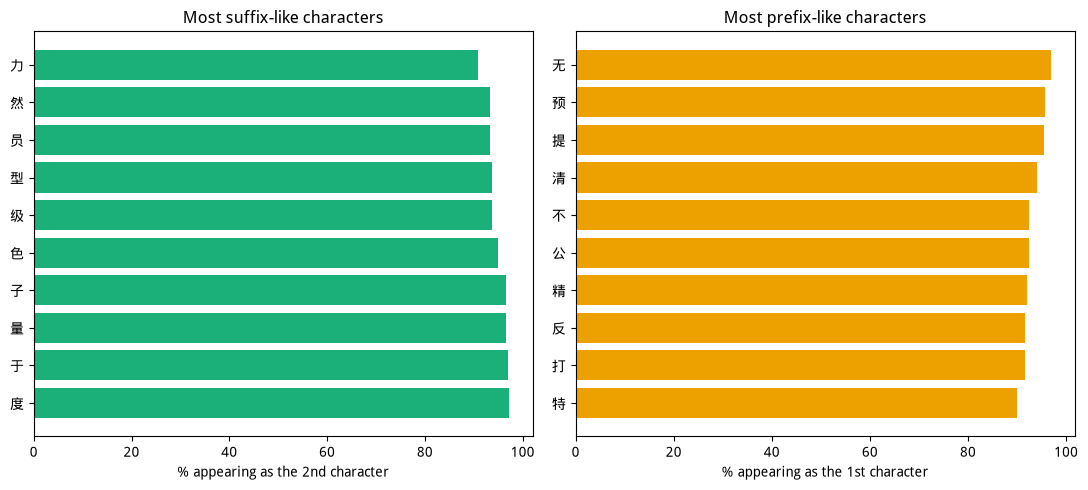

In [9]:
two_char_words = vocab.loc[vocab["Length"] == 2, "Word"]
first_pos_counter = Counter(w[0] for w in two_char_words)
second_pos_counter = Counter(w[1] for w in two_char_words)

both_positions = set(first_pos_counter) & set(second_pos_counter)
bias_rows = []
for ch in both_positions:
    first_n, second_n = first_pos_counter[ch], second_pos_counter[ch]
    total = first_n + second_n
    if total >= 15:
        bias_rows.append({"Character": ch, "As 1st char": first_n, "As 2nd char": second_n, "% as 1st char": round(100 * first_n / total, 1)})
bias_df = pd.DataFrame(bias_rows).sort_values("% as 1st char")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
suffix_like = bias_df.head(10)
prefix_like = bias_df.tail(10)
axes[0].barh(suffix_like["Character"], 100 - suffix_like["% as 1st char"], color="#1baf7a")
axes[0].set_xlabel("% appearing as the 2nd character")
axes[0].set_title("Most suffix-like characters")
axes[1].barh(prefix_like["Character"], prefix_like["% as 1st char"], color="#eda100")
axes[1].set_xlabel("% appearing as the 1st character")
axes[1].set_title("Most prefix-like characters")
plt.tight_layout()
plt.show()


This lines up with how these characters actually behave: `子`, `度`, `力`
and `员` are classic nominal suffixes (`杯子`, `速度`, `能力`, `服务员`),
while `无`, `不`, `反` and `打` head words as negation or verb prefixes
(`无关`, `不安`, `反对`, `打扫`). None of this is hand-coded — it just falls
out of counting position frequency in the parsed word list.


## 4. How much of each level is "recyclable" from earlier levels?

Since HSK is cumulative, a word in H4 built entirely out of characters you
already met in H1-H3 is easier to absorb than one introducing brand-new
characters. For each level, this counts what share of its *words* are
made purely of characters that already appeared in an earlier level.


In [10]:
level_order = list(LEVEL_LABELS.values())
seen_chars = set()
rows = []
for lvl in level_order:
    words = vocab.loc[vocab["Level"] == lvl, "Word"]
    all_known = recycled = 0
    new_chars_this_level = set()
    for word in words:
        chars = set(CJK.findall(word))
        if chars and chars.issubset(seen_chars):
            recycled += 1
        all_known += 1
        new_chars_this_level |= chars
    rows.append({"Level": lvl, "Words": all_known, "Fully recycled words": recycled,
                 "Recycled %": round(100 * recycled / all_known, 1), "New characters introduced": len(new_chars_this_level - seen_chars)})
    seen_chars |= new_chars_this_level

recycle_df = pd.DataFrame(rows).set_index("Level")
recycle_df


,Words,Fully recycled words,Recycled %,New characters introduced
Level,,,,
H1,300,0,0.0,248
H2,200,58,29.0,123
H3,500,151,30.2,283
H4,1000,343,34.3,441
H5,1600,942,58.9,431
H6,1800,1227,68.2,413
HSK 7-9,5600,3771,67.3,1148


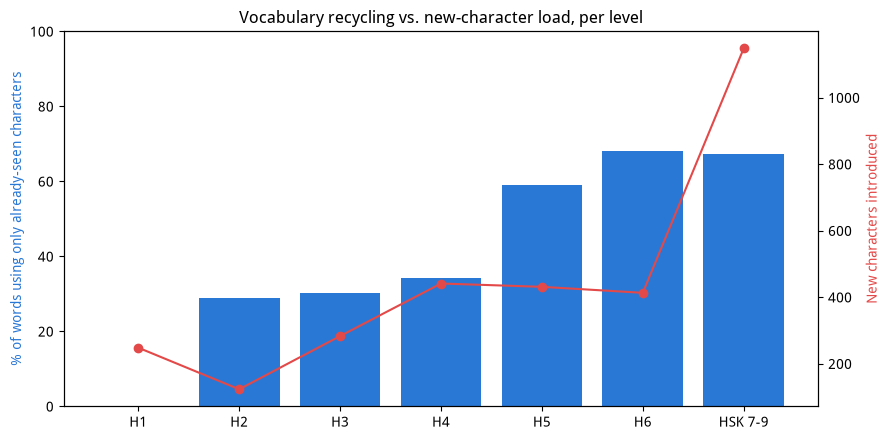

In [11]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(recycle_df.index.astype(str), recycle_df["Recycled %"], color="#2a78d6")
ax1.set_ylabel("% of words using only already-seen characters", color="#2a78d6")
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.plot(recycle_df.index.astype(str), recycle_df["New characters introduced"], color="#e34948", marker="o")
ax2.set_ylabel("New characters introduced", color="#e34948")

ax1.set_title("Vocabulary recycling vs. new-character load, per level")
plt.tight_layout()
plt.show()


H1 is unavoidably 100% new characters (there's no earlier level to draw
on). From H2 onward, a growing share of new words are recombinations of
characters already learned — which is exactly the compounding effect that
makes later HSK levels feel faster to acquire *per word*, even though each
level adds far more words than the last.


## 5. Tone distribution

Counting diacritic-marked vowels in the `Pinyin` column approximates how
often each of the four tones is used across the vocabulary. (Neutral-tone
syllables carry no diacritic and would need full syllable segmentation to
isolate reliably, so they're left out here — this only measures marked
tones 1-4.)


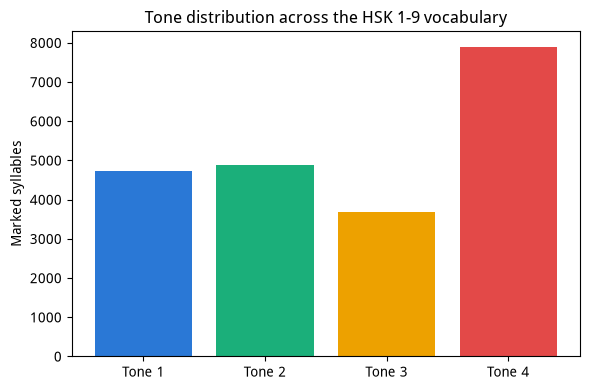

In [12]:
TONE_MARKS = {
    1: "āēīōūǖ",
    2: "áéíóúǘ",
    3: "ǎěǐǒǔǚ",
    4: "àèìòùǜ",
}
char_to_tone = {ch: tone for tone, chars in TONE_MARKS.items() for ch in chars}

tone_counter = Counter()
for pinyin in vocab["Pinyin"]:
    for ch in str(pinyin):
        if ch in char_to_tone:
            tone_counter[char_to_tone[ch]] += 1

fig, ax = plt.subplots(figsize=(6, 4))
tones = [1, 2, 3, 4]
ax.bar([f"Tone {t}" for t in tones], [tone_counter[t] for t in tones], color=["#2a78d6", "#1baf7a", "#eda100", "#e34948"])
ax.set_ylabel("Marked syllables")
ax.set_title("Tone distribution across the HSK 1-9 vocabulary")
plt.tight_layout()
plt.show()


### 5b. Tone distribution per level

Does the tone mix shift as the vocabulary grows, or does it stay roughly
constant? Same counting method as above, split out by level and normalized
to a share so levels of very different sizes are comparable.


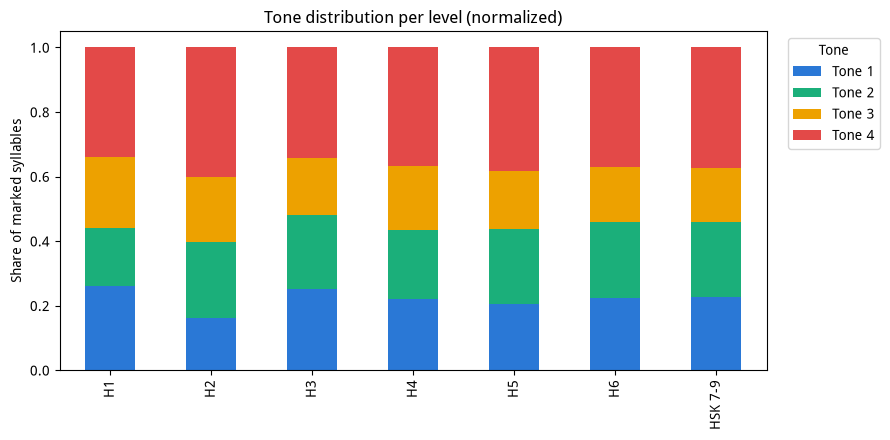

,Tone 1,Tone 2,Tone 3,Tone 4
H1,110,76,94,143
H2,48,69,59,118
H3,217,196,152,294
H4,388,380,348,648
H5,604,685,523,1129
H6,752,799,574,1249
HSK 7-9,2604,2676,1938,4314


In [13]:
tone_by_level = Counter()
tone_level_counts = {lvl: Counter() for lvl in level_order}
for lvl, pinyin in zip(vocab["Level"], vocab["Pinyin"]):
    for ch in str(pinyin):
        if ch in char_to_tone:
            tone_level_counts[lvl][char_to_tone[ch]] += 1

tone_level_df = pd.DataFrame(tone_level_counts).T.reindex(columns=[1, 2, 3, 4], fill_value=0)
tone_level_df.columns = [f"Tone {t}" for t in (1, 2, 3, 4)]
tone_level_share = tone_level_df.div(tone_level_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
tone_level_share.plot(kind="bar", stacked=True, ax=ax, color=["#2a78d6", "#1baf7a", "#eda100", "#e34948"])
ax.set_ylabel("Share of marked syllables")
ax.set_title("Tone distribution per level (normalized)")
ax.legend(title="Tone", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

tone_level_df


The tone mix is fairly stable across levels — tone 4 stays the most common
throughout, and no level swings wildly from the overall distribution. That
suggests tone 4's dominance is a structural feature of Mandarin itself
(reflected consistently at every vocabulary size), rather than an artifact
of which words HSK happens to front-load early on.


## 6. Homophone collisions

Words that sound identical (same pinyin, same tones) are a common source
of listening confusion for learners, since context alone has to do the
disambiguating work.


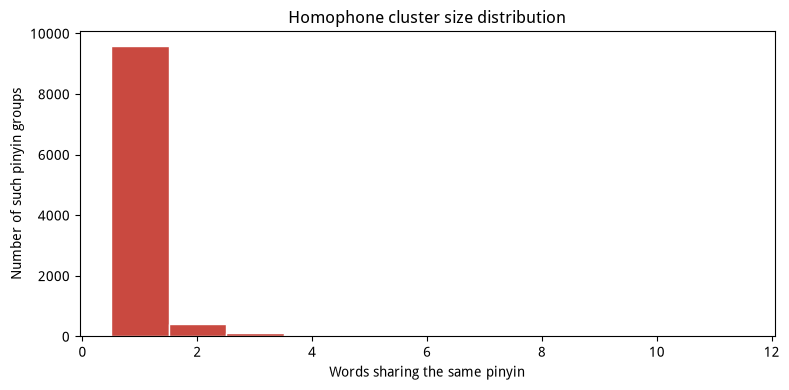

1,411 of 11,000 words (12.8%) share their pinyin with at least one other word.


In [14]:
vocab["pinyin_norm"] = vocab["Pinyin"].str.lower().str.replace(" ", "", regex=False).str.replace("-", "", regex=False)
cluster_sizes = vocab.groupby("pinyin_norm").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cluster_sizes, bins=range(1, cluster_sizes.max() + 2), align="left", color="#c94940", edgecolor="white")
ax.set_xlabel("Words sharing the same pinyin")
ax.set_ylabel("Number of such pinyin groups")
ax.set_title("Homophone cluster size distribution")
plt.tight_layout()
plt.show()

n_with_collision = int((cluster_sizes[cluster_sizes > 1]).sum())
print(f"{n_with_collision:,} of {len(vocab):,} words ({100 * n_with_collision / len(vocab):.1f}%) share their pinyin with at least one other word.")


In [15]:
biggest_clusters = cluster_sizes[cluster_sizes >= 6].sort_values(ascending=False)
examples = []
for pinyin_norm, size in biggest_clusters.items():
    words = vocab.loc[vocab["pinyin_norm"] == pinyin_norm, "Word"].tolist()
    examples.append({"Pinyin": vocab.loc[vocab["pinyin_norm"] == pinyin_norm, "Pinyin"].iloc[0], "Count": size, "Words": "、".join(words)})
pd.DataFrame(examples)


,Pinyin,Count,Words
0,jì,11,记、季、既、寄、系、计、忌、剂、继、祭、暨
1,fù,8,付、副、富、副2、负、附、赴、腹
2,jiàn,8,见、件、建、键、剑、箭、贱、溅
3,zhī,7,只、之、支、支2、枝、之2、织
4,wèi,7,喂、位、为、味、胃、喂、未
5,gōng,6,公、宫、弓、功、攻、供
6,bàn,6,半、办、扮、伴、拌、绊
7,chéng,6,城、乘、成、乘、盛、呈
8,jí,6,极、急、及、级、集、即
9,hé,6,和、河、合、何、和2、核


About one in eight words shares its exact pinyin with another word
somewhere in the list — a reminder that pinyin alone (as in, without tone
marks, the way most people type) is a much lossier signal than the hanzi
itself, and that listening practice matters as much as character
recognition for these clusters specifically.


## 7. From character count to whole-word readability

§3's coverage curve counts character *occurrences* — it doesn't say how
many whole *words* become readable. A word only counts as "readable" here
if every single character in it is already known; knowing 1 of 2 chars in
a word doesn't help you read that word at all. Ranking characters by
overall frequency (same ranking as §3) and sweeping the number "known"
from 0 up to all 3,087 shows how word-level readability actually unlocks.


In [16]:
ranked_chars = [c for c, _ in char_counter.most_common()]
word_chars = [set(CJK.findall(w)) for w in vocab["Word"]]
level_word_chars = {lvl: [set(CJK.findall(w)) for w in vocab.loc[vocab["Level"] == lvl, "Word"]] for lvl in level_order}

TIERS = {
    "Elementary (H1-H3)": ["H1", "H2", "H3"],
    "Elementary + Intermediate (H1-H6)": ["H1", "H2", "H3", "H4", "H5", "H6"],
    "Elementary + Intermediate + Advanced (H1-HSK7-9)": level_order,
}
tier_word_chars = {name: [cs for lvl in lvls for cs in level_word_chars[lvl]] for name, lvls in TIERS.items()}

def word_coverage(known_set, words_chars):
    if not words_chars:
        return 0.0
    return 100 * sum(1 for cs in words_chars if cs.issubset(known_set)) / len(words_chars)

n_values = list(range(0, len(ranked_chars) + 1, 25))
if n_values[-1] != len(ranked_chars):
    n_values.append(len(ranked_chars))

overall_curve = []
level_curves = {lvl: [] for lvl in level_order}
tier_curves = {name: [] for name in TIERS}
for n in n_values:
    known = set(ranked_chars[:n])
    overall_curve.append(word_coverage(known, word_chars))
    for lvl in level_order:
        level_curves[lvl].append(word_coverage(known, level_word_chars[lvl]))
    for name in TIERS:
        tier_curves[name].append(word_coverage(known, tier_word_chars[name]))


### 7a. Overall (all HSK 1-9 combined)


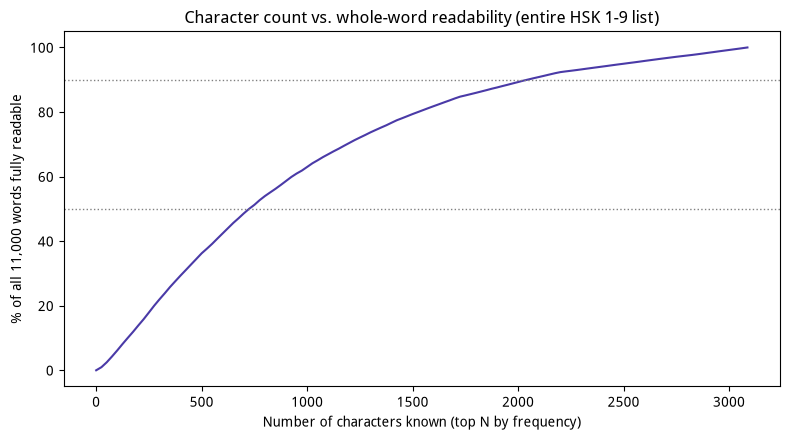

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_values, overall_curve, color="#4a3aa7")
ax.set_xlabel("Number of characters known (top N by frequency)")
ax.set_ylabel("% of all 11,000 words fully readable")
ax.set_title("Character count vs. whole-word readability (entire HSK 1-9 list)")
ax.axhline(50, color="grey", linestyle=":", linewidth=1)
ax.axhline(90, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()


### 7b. Per HSK level

Same known-character sweep, but each curve's denominator is only that
level's own word list — showing how much of *that specific level* becomes
readable as your character count grows.


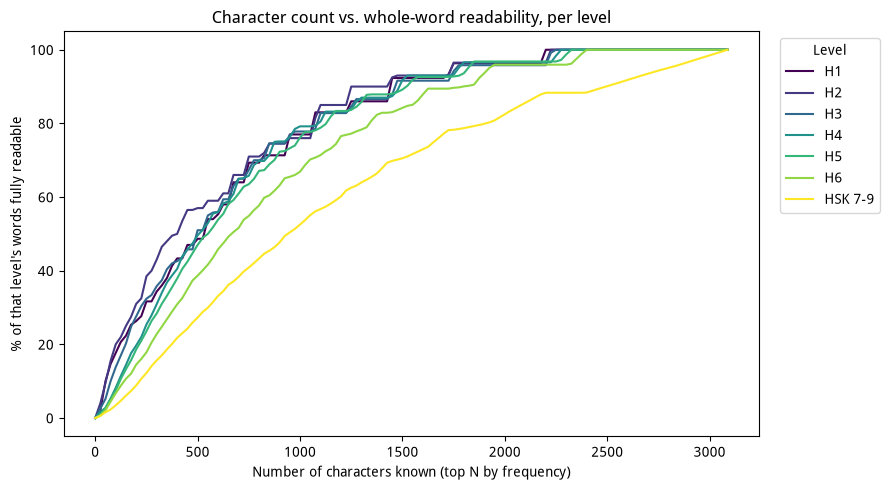

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.colormaps["viridis"].resampled(len(level_order))
for i, lvl in enumerate(level_order):
    ax.plot(n_values, level_curves[lvl], label=lvl, color=cmap(i))
ax.set_xlabel("Number of characters known (top N by frequency)")
ax.set_ylabel("% of that level's words fully readable")
ax.set_title("Character count vs. whole-word readability, per level")
ax.legend(title="Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 7c. By HSK tier (Elementary / Intermediate / Advanced, cumulative)

New HSK 3.0 groups its nine levels into three official tiers: Elementary
(H1-H3), Intermediate (H4-H6), and Advanced (HSK 7-9). This groups the
same curve by *cumulative* tier instead of individual level.


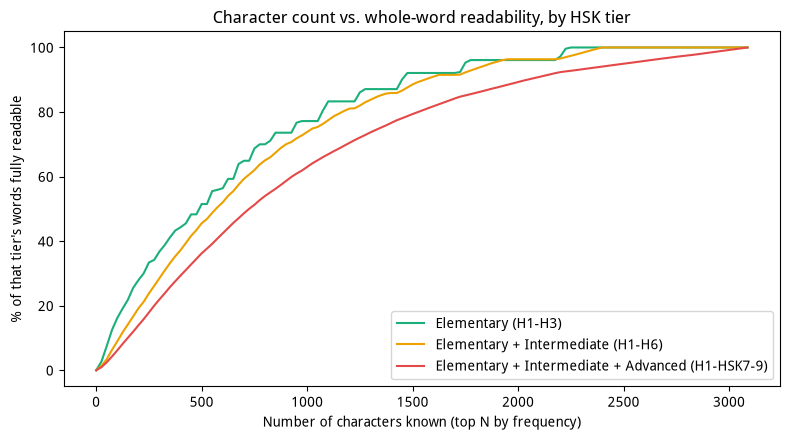

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#1baf7a", "#eda100", "#e34948"]
for (name, curve), color in zip(tier_curves.items(), colors):
    ax.plot(n_values, curve, label=name, color=color)
ax.set_xlabel("Number of characters known (top N by frequency)")
ax.set_ylabel("% of that tier's words fully readable")
ax.set_title("Character count vs. whole-word readability, by HSK tier")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [20]:
checkpoints = [100, 300, 500, 1000, 1500, 2000, 2500, 3087]
summary_rows = []
for n in checkpoints:
    known = set(ranked_chars[:n])
    row = {"Characters known": n, "Overall": round(word_coverage(known, word_chars), 1)}
    for lvl in level_order:
        row[lvl] = round(word_coverage(known, level_word_chars[lvl]), 1)
    for name in TIERS:
        row[name] = round(word_coverage(known, tier_word_chars[name]), 1)
    summary_rows.append(row)

pd.DataFrame(summary_rows).set_index("Characters known")


,Overall,H1,H2,H3,H4,H5,H6,HSK 7-9,Elementary (H1-H3),Elementary + Intermediate (H1-H6),Elementary + Intermediate + Advanced (H1-HSK7-9)
Characters known,,,,,,,,,,,
100,6.2,17.7,20.0,13.8,8.2,7.4,6.7,3.5,16.2,9.0,6.2
300,22.0,34.3,43.0,35.8,30.9,28.4,22.8,15.6,36.8,28.5,22.0
500,36.2,48.7,57.0,51.0,49.6,47.0,38.7,27.3,51.5,45.5,36.2
1000,63.0,77.0,76.0,77.8,79.2,76.2,66.9,52.5,77.2,73.8,63.0
1500,79.4,92.3,93.0,91.6,91.8,89.2,84.2,70.5,92.1,88.6,79.4
2000,89.3,96.3,96.5,95.8,96.6,96.8,95.9,82.5,96.1,96.4,89.3
2500,95.0,100.0,100.0,100.0,100.0,100.0,100.0,90.1,100.0,100.0,95.0
3087,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


The gap between levels is stark at low character counts: at 500 characters
known, H2 words are already ~57% readable while HSK 7-9 words are only
~27% readable, because HSK 7-9 leans on a much longer tail of rarer
characters (§3's `3,087 unique hanzi` figure is dominated by this level).
That gap narrows steadily and only fully closes at the very end of the
curve, when every character has been learned — confirming quantitatively
what §4's recycling analysis suggested: earlier levels are disproportionately
"free" once you've front-loaded the highest-frequency characters, while
HSK 7-9 keeps demanding new, rarer characters almost until the end.


### 7d. Using actual curriculum order instead of frequency rank

§7a-7c all assume characters are learned in pure frequency order, which is
optimistic — a real learner studying HSK level by level meets whatever
characters that level happens to introduce, not the globally most frequent
ones first. This redoes the same "readable if every character is known"
test, but with the *known set* built the way HSK is actually studied:
cumulatively, level by level (H1, then H1+H2, then H1+H2+H3, ...).


In [21]:
cumulative_known = set()
matrix_rows = []
for completed_lvl in level_order:
    cumulative_known |= set().union(*level_word_chars[completed_lvl]) if level_word_chars[completed_lvl] else set()
    row = {"Completed through": completed_lvl, "Overall": round(word_coverage(cumulative_known, word_chars), 1)}
    for target_lvl in level_order:
        row[target_lvl] = round(word_coverage(cumulative_known, level_word_chars[target_lvl]), 1)
    matrix_rows.append(row)

readability_matrix = pd.DataFrame(matrix_rows).set_index("Completed through")
readability_matrix


,Overall,H1,H2,H3,H4,H5,H6,HSK 7-9
Completed through,,,,,,,,
H1,8.1,100.0,29.0,21.0,7.8,5.8,5.8,2.7
H2,13.9,100.0,100.0,30.2,15.4,11.6,10.4,6.2
H3,29.3,100.0,100.0,100.0,34.3,30.0,24.9,17.0
H4,53.2,100.0,100.0,100.0,100.0,58.9,48.9,36.2
H5,71.4,100.0,100.0,100.0,100.0,100.0,68.2,54.1
H6,83.4,100.0,100.0,100.0,100.0,100.0,100.0,67.3
HSK 7-9,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


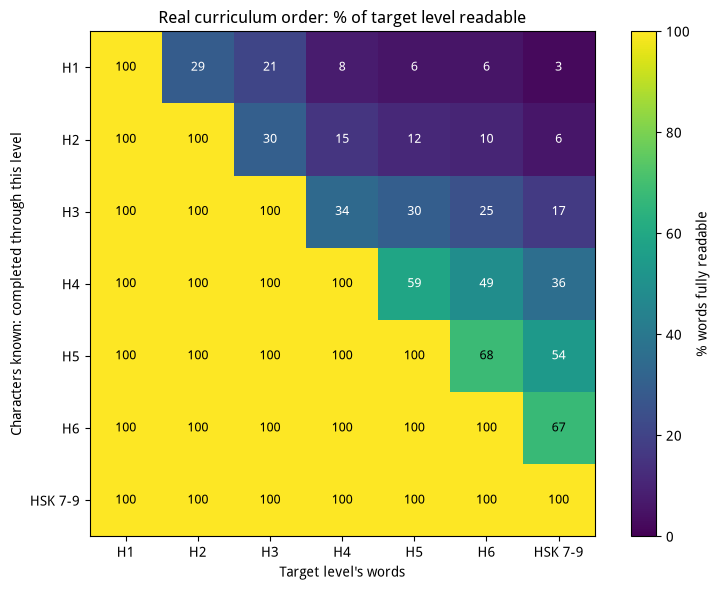

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
data = readability_matrix[level_order].values
im = ax.imshow(data, cmap="viridis", vmin=0, vmax=100)
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(level_order)
ax.set_yticks(range(len(level_order)))
ax.set_yticklabels(level_order)
ax.set_xlabel("Target level's words")
ax.set_ylabel("Characters known: completed through this level")
ax.set_title("Real curriculum order: % of target level readable")
for i in range(len(level_order)):
    for j in range(len(level_order)):
        val = data[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", color="white" if val < 60 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="% words fully readable")
plt.tight_layout()
plt.show()


Reading a row shows what finishing a given level unlocks *ahead* of where
you are: after H3 (finishing Elementary) you can already read 34.3% of H4,
30.0% of H5, 24.9% of H6 and 17.0% of HSK 7-9 without learning a single new
character (matches §4's H4 "Recycled %" of 34.3% exactly, since that's the
same calculation — this table just extends it to *every* later level, not
only the next one). The cells at or below the diagonal are always 100% by
definition: you can't fail to read a level's own words using characters
that level itself contributed.


In [23]:
TIER_LEVELS = {"Elementary": ["H1", "H2", "H3"], "Intermediate": ["H4", "H5", "H6"], "Advanced": ["HSK 7-9"]}
tier_only_chars = {name: [cs for lvl in lvls for cs in level_word_chars[lvl]] for name, lvls in TIER_LEVELS.items()}

tier_cum_known = set()
tier_matrix_rows = []
for tier_name, lvls in TIER_LEVELS.items():
    for lvl in lvls:
        for cs in level_word_chars[lvl]:
            tier_cum_known |= cs
    row = {"Completed": tier_name}
    for target_name in TIER_LEVELS:
        row[target_name] = round(word_coverage(tier_cum_known, tier_only_chars[target_name]), 1)
    tier_matrix_rows.append(row)

pd.DataFrame(tier_matrix_rows).set_index("Completed")


,Elementary,Intermediate,Advanced
Completed,,,
Elementary,100.0,28.9,17.0
Intermediate,100.0,100.0,67.3
Advanced,100.0,100.0,100.0


Collapsed to the three official tiers: finishing **Elementary** alone
already makes **28.9%** of Intermediate and **17.0%** of Advanced
vocabulary readable word-for-word. Finishing **Intermediate** pushes
Advanced readability to **67.3%** — meaning by the time a learner reaches
HSK 7-9, two-thirds of its words are already decodable purely from
characters picked up along the way, not from any dedicated HSK 7-9 study.


## Takeaways for learners

Turning the numbers above into actual study advice — each point cites the
section it comes from.

1. **Overlearn H1 rather than rushing through it.** H1 is 100% brand-new
   characters with nothing earlier to lean on (§4), but those are also the
   highest-frequency, most reusable characters in the language: the top
   362 characters alone already cover 50% of every character occurrence
   in the full 11,000-word list, and the top 1,064 cover 80% (§3). Time
   spent drilling H1 characters to automaticity pays off at every level
   above it, not just H1 itself.

2. **When you hit an unfamiliar 2-character word, guess from position,
   not just meaning.** Characters like `子`, `度`, `员`, `力` behave almost
   exclusively as the *second* character (nominal suffixes, as in `杯子`,
   `速度`, `服务员`), while `无`, `不`, `反`, `打` behave almost exclusively
   as the *first* (negation/verb prefixes, as in `无关`, `不安`, `反对`)
   (§3b). Recognizing these patterns lets you decompose new compounds
   instead of memorizing each one from scratch.

3. **Budget more study time per level as you advance, not less.** Words
   get measurably longer — average length rises from 1.61 characters at
   H1 to 2.10 at HSK 7-9 (§1b) — and recycled words (built entirely from
   characters you already know) jump from 0% at H1 to 58-68% from H5
   onward (§4). In practice this means late levels *feel* faster per word
   but still take real time, since there are far more words and each one
   is longer.

4. **Don't trust pinyin alone once you're past the first couple of
   levels.** 1,411 of 11,000 words (12.8%) share their exact pinyin,
   tones included, with at least one other word — e.g. `jì` alone maps to
   11 different words (`记`, `季`, `既`, `寄`, `系`, `计`, `忌`, `剂`, `继`,
   `祭`, `暨`) (§6). If you're learning by ear or by typing pinyin,
   double-check the hanzi; tone alone won't disambiguate these clusters.

5. **Drill tone 4 relative to the others deliberately** — it's the single
   most common marked tone at every level without exception, not just
   in aggregate (§5, §5b). Since it stays dominant regardless of which
   words a given level happens to introduce, it's worth extra ear-training
   investment early rather than assuming exposure alone will fix it.

6. **Treat HSK 7-9 as a raw word list, not a finished study set.** Its
   source data is visibly less curated than every earlier level — no
   translation column at all, and a 7.9% blank part-of-speech rate versus
   0.6-2.0% for H1-H6 (§2b). Cross-reference a dictionary for meaning and
   usage at that tier rather than relying on this list alone.

7. **Expect grammar, not just vocabulary, to get more demanding in the
   middle levels.** The share of words carrying more than one POS tag
   (genuinely multi-function words) rises from 10.3% at H1 to a peak of
   19.0% at H2 and stays in the 11-17% range through H6, before dropping
   back to 8.0% at HSK 7-9 (§2b) — while adjectives and classifiers
   ('measure words') pick up overall share through the middle levels too
   (§2). Mid-level study benefits from explicitly drilling how a word's
   grammatical role shifts with context, not just its meaning.

8. **Set a character-count goal, not just a level-completion goal.**
   Knowing the ~1,500 most frequent characters already makes 89-93% of
   every H1-H6 level fully readable word-for-word, but only 70.5% of
   HSK 7-9 (§7b, §7c) — HSK 7-9 needs real breadth in rarer characters,
   not just "one more level" of vocabulary drilling. Tracking your unique
   character count (e.g. with §3's ranking) is a more honest progress
   metric than words memorized, since a handful of unknown characters can
   quietly block a much larger share of words than they seem to.

9. **Trust that finishing a level pays off ahead of schedule, not just at
   its own level.** Following the real HSK study order (not an idealized
   frequency ranking), finishing Elementary (H1-H3) already makes 17.0% of
   Advanced (HSK 7-9) vocabulary readable, and finishing Intermediate
   (H4-H6) pushes that to 67.3% (§7d) — entirely from characters picked up
   along the normal curriculum, with zero dedicated HSK 7-9 study. If HSK
   7-9 feels intimidating from the outside, this is a concrete reason it's
   more approachable than its 5,600-word size suggests once you actually
   arrive there.
